In [1]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager
from matplotlib.cm import get_cmap

import pickle
import math
import numpy as np
import pandas as pd
import random

In [2]:
from IPython.display import clear_output
from IPython.core.display import HTML
HTML("<style>.container { width:98% !important; }</style>")

In [3]:
os.chdir("..")
print("Current working directory:", os.getcwd())

Current working directory: /home/junhyug/SPOC_active_learning


In [4]:
from builder import build_dataset, build_model, build_scaler, build_acquisition
from utils import config_util

In [5]:
config_dir = "./configs"
config_files = "polymer_rf.yaml"

configs = config_util.load_configs(os.path.join(config_dir, config_files))
configs

{'data': {'name': 'polymer_v4', 'material': None, 'print_type': None},
 'model': {'name': 'random_forest',
  'params': {'n_estimators': 100, 'n_jobs': -1}},
 'train': {'n_seeds': 500,
  'n_initial': 2,
  'top_ratio': 0.1,
  'scaler': 'standard',
  'acquisition': 'EI'}}

In [6]:
# Set the final configurations
configs['data']['print_type'] = 'PCB'
configs['model']['params']['n_estimators'] = 100
configs['train']['acquisition'] = 'PI'

configs

{'data': {'name': 'polymer_v4', 'material': None, 'print_type': 'PCB'},
 'model': {'name': 'random_forest',
  'params': {'n_estimators': 100, 'n_jobs': -1}},
 'train': {'n_seeds': 500,
  'n_initial': 2,
  'top_ratio': 0.1,
  'scaler': 'standard',
  'acquisition': 'PI'}}

In [7]:
dataset = build_dataset(configs["data"])
dataset.df

[2025-07-14 16:22:16,944] Preprocess dataset..
[2025-07-14 16:22:16,945]  - Shape (Before): (1300, 5)
[2025-07-14 16:22:16,947]  - Categorical (2) / Numerical (3)
[2025-07-14 16:22:16,963]  - Shape (After) : (90, 6)


,fcomp_additive_wt_pct,fcomp_salt_wt_pct,material_LiTFSI,material_NaTFSI,print_type_PCB,ionic_conductivity_final
0,0.0,0.0,0.0,1.0,1.0,-5.927169e-07
1,0.0,0.0,1.0,0.0,1.0,-4.243117e-07
2,0.0,2.9,0.0,1.0,1.0,-1.302684e-06
3,0.0,4.3,1.0,0.0,1.0,-2.739800e-06
4,0.0,5.7,0.0,1.0,1.0,-1.614583e-06
...,...,...,...,...,...,...
85,15.0,17.0,1.0,0.0,1.0,-2.365138e-06
86,15.0,20.0,1.0,0.0,1.0,-3.691816e-06
87,15.0,21.0,1.0,0.0,1.0,-5.751356e-06
88,15.0,26.0,1.0,0.0,1.0,-5.710516e-06


In [8]:
scaler = build_scaler(configs["train"]["scaler"])
acquisition = build_acquisition(configs["train"]["acquisition"])

In [9]:
model = build_model(configs["model"], input_dim=len(dataset.features))
model

In [12]:
x, y = dataset.get_data()
scaler.fit(x)
x_train = scaler.transform(x)
y_train = np.array(y)
model.train(x_train, y_train)

In [13]:
# Variable scopes
bounds = [(0.0, 15.0), (0.0, 30.0)]
material_opts = np.array([[1, 0], [0, 1]])

In [ ]:
def objective(x_cont, mat_flags, y_best, return_acq=True):
    """
    x_cont: shape (2,)  -> Additive, Salt
    mat_flags: shape (2,) -> [material_LiTFSI, material_NaTFSI]
    """
    x_full = np.hstack([x_cont, mat_flags, [1]]).reshape(1, -1)  # print_type_PCB = 1
    x_full = scaler.transform(x_full)
    mean, std = model.get_mean_std(x_full)
    acq = -acquisition(mean, std, y_best=y_best)
    return acq if return_acq else mean

### Recommend by Target Prediction (Ionic Conductivity)

In [91]:
from scipy.optimize import minimize

return_acq = False
bounds_cont = [(0.0, 15.0), (0.0, 30.0)]
best = {'material': None, 'x_cont': None, 'score': np.inf}

for mat_flags in material_opts:
    for x0 in np.random.uniform([b[0] for b in bounds_cont],
                                [b[1] for b in bounds_cont],
                                size=(500, 2)):
        res = minimize(lambda x: objective(x, mat_flags, y_best=np.min(y), return_acq=return_acq),
                       x0=x0, bounds=bounds_cont)
        if res.fun < best['score']:
            best['score'] = res.fun
            best['x_cont'] = res.x
            best['material'] = mat_flags

suggested_cont = best['x_cont']
suggested_cont_rounded = np.round(suggested_cont, 1)
suggested_material = 'LiTFSI' if best['material'][0] == 1 else 'NaTFSI'

df_suggestion = pd.DataFrame({
    'Parameter': ['Additive Weight (%)', 'Salt Weight (%)', 'Material', 'Print Type (PCB)'],
    'Suggested Continuous': [suggested_cont[0], suggested_cont[1], suggested_material, 1],
    'Suggested for Experiment': [suggested_cont_rounded[0], suggested_cont_rounded[1], suggested_material, 1]
})

df_suggestion

,Parameter,Suggested Continuous,Suggested for Experiment
0,Additive Weight (%),13.436613,13.4
1,Salt Weight (%),9.440509,9.4
2,Material,LiTFSI,LiTFSI
3,Print Type (PCB),1,1


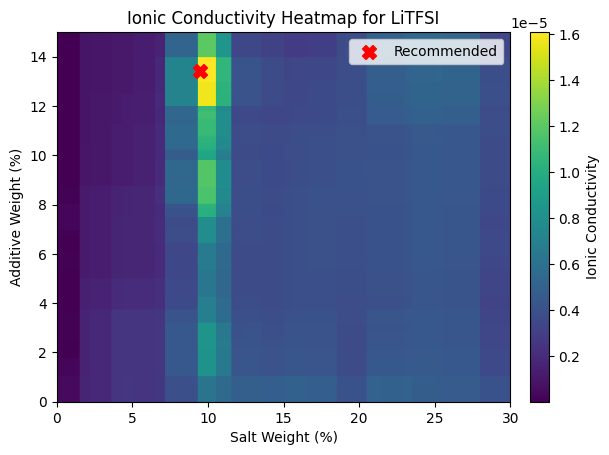

In [92]:
from matplotlib.colors import LogNorm

# Recommended material (e.g., NaTFSI)
mat_flags = np.array([1, 0])
print_type_flag = 1

# Grid generation
add_vals = np.linspace(0, 15, 500)
salt_vals = np.linspace(0, 30, 500)
grid = np.array([[a, s] for a in add_vals for s in salt_vals])

x_grid = np.hstack([
    grid,
    np.tile(mat_flags, (grid.shape[0], 1)),
    np.ones((grid.shape[0], 1)) * print_type_flag
])

x_grid = scaler.transform(x_grid)
mean, std = model.get_mean_std(x_grid)
acq = -acquisition(mean, std, np.min(y))

best_add, best_salt = suggested_cont
Z = (-mean).reshape(len(add_vals), len(salt_vals))

fig, ax = plt.subplots()
im = ax.imshow(
    Z,
    origin='lower',
    extent=[salt_vals.min(), salt_vals.max(), add_vals.min(), add_vals.max()],
    aspect='auto',
    # interpolation='bilinear'
)

ax.scatter(best_salt, best_add,
           color='red', marker='X', s=100, label='Recommended')
ax.legend(loc='upper right')

ax.set_xlabel('Salt Weight (%)')
ax.set_ylabel('Additive Weight (%)')
ax.set_title('Ionic Conductivity Heatmap for LiTFSI')

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Ionic Conductivity')

plt.show()

In [97]:
threshold = 1 * Z.max()
mask = Z >= threshold

rows, cols = np.where(mask)
add_min, add_max = add_vals[rows.min()], add_vals[rows.max()]
salt_min, salt_max = salt_vals[cols.min()], salt_vals[cols.max()]

df_region = pd.DataFrame({
    'Variable': ['Additive Weight (%)', 'Salt Weight (%)'],
    'Min': [add_min, salt_min],
    'Max': [add_max, salt_max]
})

print(df_region)

              Variable        Min        Max
0  Additive Weight (%)  13.016032  13.977956
1      Salt Weight (%)   9.318637  10.460922


### Recommend by Acquisition Function

In [93]:
return_acq = True
bounds_cont = [(0.0, 15.0), (0.0, 30.0)]
best = {'material': None, 'x_cont': None, 'score': np.inf}

for mat_flags in material_opts:
    for x0 in np.random.uniform([b[0] for b in bounds_cont],
                                [b[1] for b in bounds_cont],
                                size=(500, 2)):
        res = minimize(lambda x: objective(x, mat_flags, y_best=np.min(y), return_acq=return_acq),
                       x0=x0, bounds=bounds_cont)
        if res.fun < best['score']:
            best['score'] = res.fun
            best['x_cont'] = res.x
            best['material'] = mat_flags

# 최종 추천 조성
suggested_cont = best['x_cont']
suggested_cont_rounded = np.round(suggested_cont, 1)
suggested_material = 'LiTFSI' if best['material'][0] == 1 else 'NaTFSI'

df_suggestion = pd.DataFrame({
    'Parameter': ['Additive Weight (%)', 'Salt Weight (%)', 'Material', 'Print Type (PCB)'],
    'Suggested Continuous': [suggested_cont[0], suggested_cont[1], suggested_material, 1],
    'Suggested for Experiment': [suggested_cont_rounded[0], suggested_cont_rounded[1], suggested_material, 1]
})

df_suggestion

,Parameter,Suggested Continuous,Suggested for Experiment
0,Additive Weight (%),13.355317,13.4
1,Salt Weight (%),10.008226,10.0
2,Material,LiTFSI,LiTFSI
3,Print Type (PCB),1,1


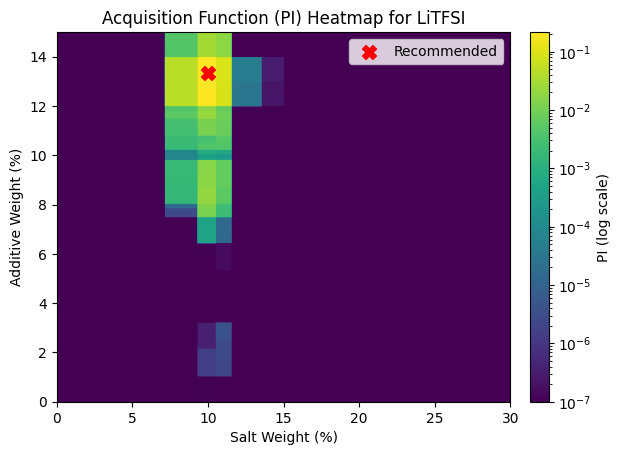

In [94]:
from matplotlib.colors import LogNorm

mat_flags = np.array([1, 0])
print_type_flag = 1

add_vals = np.linspace(0, 15, 500)
salt_vals = np.linspace(0, 30, 500)
grid = np.array([[a, s] for a in add_vals for s in salt_vals])

x_grid = np.hstack([
    grid,
    np.tile(mat_flags, (grid.shape[0], 1)),
    np.ones((grid.shape[0], 1)) * print_type_flag
])

x_grid = scaler.transform(x_grid)
mean, std = model.get_mean_std(x_grid)
acq = -acquisition(mean, std, np.min(y))

best_add, best_salt = suggested_cont
Z = (-acq + 1e-7).reshape(len(add_vals), len(salt_vals))

fig, ax = plt.subplots()
im = ax.imshow(
    Z,
    origin='lower',
    extent=[salt_vals.min(), salt_vals.max(), add_vals.min(), add_vals.max()],
    aspect='auto',
    norm=LogNorm(vmin=Z.min(), vmax=Z.max()),
    # interpolation='bicubic'
)

ax.scatter(best_salt, best_add,
           color='red', marker='X', s=100, label='Recommended')
ax.legend(loc='upper right')

ax.set_xlabel('Salt Weight (%)')
ax.set_ylabel('Additive Weight (%)')
ax.set_title('Acquisition Function (PI) Heatmap for LiTFSI')

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('PI (log scale)')

plt.show()